# 🌍⚡ Global Energy Production & Consumption — Data Preprocessing
**Project 9 | Data Visualization Course**

This notebook covers:
1. Loading & initial exploration
2. Filtering & cleaning
3. Handling missing values
4. Feature engineering
5. Continent mapping
6. Exporting the cleaned dataset

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2️⃣ Load Raw Data

In [2]:
# Load the raw dataset
df_raw = pd.read_csv('/content/owid-energy-data.csv')

print(f'Shape: {df_raw.shape}')
print(f'Years range: {df_raw["year"].min()} → {df_raw["year"].max()}')
print(f'Total unique countries/regions: {df_raw["country"].nunique()}')
df_raw.head(3)

Shape: (23377, 130)
Years range: 1900 → 2025
Total unique countries/regions: 314


,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,biofuel_share_energy,carbon_intensity_elec,coal_cons_change_pct,coal_cons_change_twh,coal_cons_per_capita,coal_consumption,coal_elec_per_capita,coal_electricity,coal_prod_change_pct,coal_prod_change_twh,coal_prod_per_capita,coal_production,coal_share_elec,...,primary_energy_consumption,renewables_cons_change_pct,renewables_cons_change_twh,renewables_consumption,renewables_elec_per_capita,renewables_electricity,renewables_energy_per_capita,renewables_share_elec,renewables_share_energy,solar_cons_change_pct,solar_cons_change_twh,solar_consumption,solar_elec_per_capita,solar_electricity,solar_energy_per_capita,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.87,1.55,NaN,572.58,NaN,NaN,NaN,NaN,NaN,76.03,NaN,NaN,NaN,NaN,20.07,...,NaN,NaN,NaN,NaN,NaN,73.23,NaN,19.33,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.46,1.59,NaN,570.27,NaN,NaN,NaN,NaN,NaN,86.26,NaN,NaN,NaN,NaN,21.29,...,NaN,NaN,NaN,NaN,NaN,77.19,NaN,19.05,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.62,1.53,NaN,572.68,NaN,NaN,NaN,NaN,NaN,93.43,NaN,NaN,NaN,NaN,21.57,...,NaN,NaN,NaN,NaN,NaN,76.53,NaN,17.67,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN


In [3]:
# Check column names
print('All columns:')
for i, col in enumerate(df_raw.columns):
    print(f'  {i:3d}. {col}')

All columns:
    0. country
    1. year
    2. iso_code
    3. population
    4. gdp
    5. biofuel_cons_change_pct
    6. biofuel_cons_change_twh
    7. biofuel_cons_per_capita
    8. biofuel_consumption
    9. biofuel_elec_per_capita
   10. biofuel_electricity
   11. biofuel_share_elec
   12. biofuel_share_energy
   13. carbon_intensity_elec
   14. coal_cons_change_pct
   15. coal_cons_change_twh
   16. coal_cons_per_capita
   17. coal_consumption
   18. coal_elec_per_capita
   19. coal_electricity
   20. coal_prod_change_pct
   21. coal_prod_change_twh
   22. coal_prod_per_capita
   23. coal_production
   24. coal_share_elec
   25. coal_share_energy
   26. electricity_demand
   27. electricity_demand_per_capita
   28. electricity_generation
   29. electricity_share_energy
   30. energy_cons_change_pct
   31. energy_cons_change_twh
   32. energy_per_capita
   33. energy_per_gdp
   34. fossil_cons_change_pct
   35. fossil_cons_change_twh
   36. fossil_elec_per_capita
   37. fossil_ele

In [4]:
# Basic info
df_raw.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


## 3️⃣ Filter: Real Countries Only (Remove Aggregates)

In [5]:
# Rows WITHOUT iso_code are continent/region aggregates (e.g. 'Africa', 'Asia')
# We keep only real countries that have an iso_code

aggregates = df_raw[df_raw['iso_code'].isna()]['country'].unique()
print(f'Aggregates removed ({len(aggregates)} regions):')
print(list(aggregates)[:15], '...')

df = df_raw[df_raw['iso_code'].notna()].copy()
print(f'\nAfter removing aggregates: {df.shape}')
print(f'Unique real countries: {df["country"].nunique()}')

Aggregates removed (94 regions):
['ASEAN (Ember)', 'Africa', 'Africa (EI)', 'Africa (EIA)', 'Africa (Ember)', 'Africa (Shift)', 'Asia', 'Asia (Ember)', 'Asia Pacific (EI)', 'Asia and Oceania (EIA)', 'Asia and Oceania (Shift)', 'Australia and New Zealand (EIA)', 'CIS (EI)', 'Central America (EI)', 'Central and South America (EIA)'] ...

After removing aggregates: (17265, 130)
Unique real countries: 220


## 4️⃣ Filter: Year Range 2000–2023

In [6]:
# Data before 2000 is very sparse for most columns
# We focus on 2000-2023 for meaningful analysis

df = df[df['year'].between(2000, 2023)].copy()
print(f'After year filter (2000-2023): {df.shape}')

# Verify
print(f'Years in dataset: {df["year"].min()} → {df["year"].max()}')

After year filter (2000-2023): (5260, 130)
Years in dataset: 2000 → 2023


## 5️⃣ Select Relevant Columns

In [7]:
# Select the columns needed for all dashboard charts
columns_to_keep = [
    # Identifiers
    'country', 'year', 'iso_code',

    # Population & Economy
    'population', 'gdp',

    # Total Energy
    'primary_energy_consumption',   # TWh
    'energy_per_capita',            # kWh per person
    'energy_per_gdp',               # kWh per $ GDP

    # Fossil Fuels
    'coal_consumption',
    'gas_consumption',
    'oil_consumption',
    'fossil_fuel_consumption',
    'fossil_share_energy',          # % of total

    # Renewables
    'renewables_consumption',
    'renewables_share_energy',      # % of total
    'solar_consumption',
    'wind_consumption',
    'hydro_consumption',
    'biofuel_consumption',

    # Electricity sources (TWh)
    'electricity_generation',
    'solar_electricity',
    'wind_electricity',
    'hydro_electricity',
    'nuclear_electricity',
    'coal_electricity',
    'gas_electricity',
    'oil_electricity',

    # Share of electricity
    'renewables_share_elec',
    'fossil_share_elec',
    'solar_share_elec',
    'wind_share_elec',

    # Nuclear
    'nuclear_consumption',
    'nuclear_share_elec',

    # Emissions
    'greenhouse_gas_emissions',
    'carbon_intensity_elec',        # gCO2 per kWh electricity

    # Per capita electricity
    'per_capita_electricity',
]

df = df[columns_to_keep].copy()
print(f'Dataset shape after column selection: {df.shape}')
df.head()

Dataset shape after column selection: (5260, 36)


,country,year,iso_code,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp,coal_consumption,gas_consumption,oil_consumption,fossil_fuel_consumption,fossil_share_energy,renewables_consumption,renewables_share_energy,solar_consumption,wind_consumption,hydro_consumption,biofuel_consumption,electricity_generation,solar_electricity,wind_electricity,hydro_electricity,nuclear_electricity,coal_electricity,gas_electricity,oil_electricity,renewables_share_elec,fossil_share_elec,solar_share_elec,wind_share_elec,nuclear_consumption,nuclear_share_elec,greenhouse_gas_emissions,carbon_intensity_elec,per_capita_electricity
126,Afghanistan,2000,AFG,20130334.00,11283794151.00,5.29,262.68,0.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.48,0.00,0.00,0.31,0.00,0.00,0.00,0.17,64.58,35.42,0.00,0.00,NaN,0.00,0.12,250.00,23.84
127,Afghanistan,2001,AFG,20284303.00,11021272927.00,3.65,179.89,0.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.69,0.00,0.00,0.50,0.00,0.04,0.00,0.15,72.46,27.54,0.00,0.00,NaN,0.00,0.15,217.39,34.02
128,Afghanistan,2002,AFG,21378123.00,18804871508.00,3.33,155.69,0.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.71,0.00,0.00,0.56,0.00,0.04,0.00,0.11,78.87,21.13,0.00,0.00,NaN,0.00,0.12,169.01,33.21
129,Afghanistan,2003,AFG,22733053.00,21074343420.00,3.97,174.56,0.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.91,0.00,0.00,0.63,0.00,0.09,0.00,0.19,69.23,30.77,0.00,0.00,NaN,0.00,0.22,241.76,40.03
130,Afghanistan,2004,AFG,23560656.00,22332570533.00,3.72,157.76,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.79,0.00,0.00,0.56,0.00,0.06,0.00,0.17,70.89,29.11,0.00,0.00,NaN,0.00,0.18,227.85,33.53


## 6️⃣ Analyze Missing Values

In [8]:
# Calculate missing % per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('Missing values per column:')
print(missing_df[missing_df['Missing Count'] > 0].to_string())

Missing values per column:
                            Missing Count  Missing %
coal_consumption                     3364      64.00
gas_consumption                      3364      64.00
oil_consumption                      3364      64.00
fossil_fuel_consumption              3364      64.00
wind_consumption                     3364      64.00
hydro_consumption                    3364      64.00
renewables_consumption               3364      64.00
fossil_share_energy                  3364      64.00
solar_consumption                    3364      64.00
renewables_share_energy              3364      64.00
biofuel_consumption                  2759      52.50
nuclear_consumption                  2687      51.10
energy_per_gdp                       1477      28.10
gdp                                  1470      27.90
wind_share_elec                       386       7.30
wind_electricity                      361       6.90
nuclear_share_elec                    342       6.50
gas_electricity    

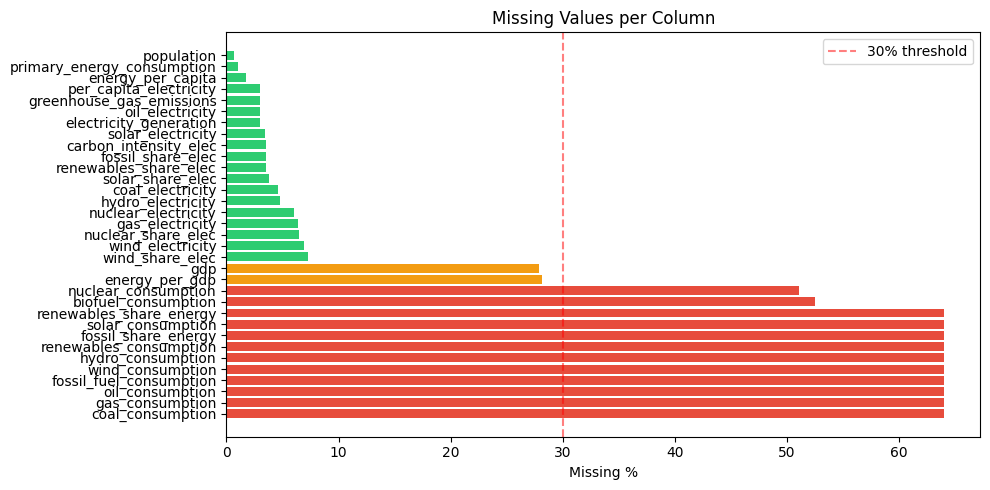


🟢 Green < 10% | 🟡 Orange 10-30% | 🔴 Red > 30%


In [9]:
# Visualize missing values heatmap
fig, ax = plt.subplots(figsize=(10, 5))
missing_cols = missing_df[missing_df['Missing %'] > 0].index.tolist()
missing_pct_vals = missing_df.loc[missing_cols, 'Missing %']

colors = ['#2ecc71' if x < 10 else '#f39c12' if x < 30 else '#e74c3c' for x in missing_pct_vals]
bars = ax.barh(missing_cols, missing_pct_vals, color=colors)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column')
ax.axvline(x=30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print('\n🟢 Green < 10% | 🟡 Orange 10-30% | 🔴 Red > 30%')

## 7️⃣ Handle Missing Values

In [10]:
# Strategy:
# - Consumption/share columns: fill 0 if country truly has none of that source
#   (e.g. a small country with no nuclear → nuclear_consumption NaN means 0)
# - GDP: forward-fill then backward-fill within country (economic data stable)
# - Keep NaN for country-years with completely missing data (will be excluded per chart)

# Sort by country and year first
df = df.sort_values(['country', 'year']).reset_index(drop=True)

# Fill energy source columns: NaN → 0
# (A country with no solar/wind/nuclear simply has 0, not missing)
zero_fill_cols = [
    'coal_consumption', 'gas_consumption', 'oil_consumption',
    'solar_consumption', 'wind_consumption', 'hydro_consumption',
    'biofuel_consumption', 'nuclear_consumption', 'renewables_consumption',
    'solar_electricity', 'wind_electricity', 'hydro_electricity',
    'nuclear_electricity', 'coal_electricity', 'gas_electricity', 'oil_electricity',
    'solar_share_elec', 'wind_share_elec', 'nuclear_share_elec',
]

for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print('✅ Zero-filled energy source columns')

# GDP: forward fill then backward fill within each country group
df['gdp'] = df.groupby('country')['gdp'].transform(lambda x: x.ffill().bfill())
print('✅ GDP filled (forward/backward fill per country)')

# Remaining nulls check
print(f'\nRemaining nulls:')
rem = df.isnull().sum()
print(rem[rem > 0])

✅ Zero-filled energy source columns
✅ GDP filled (forward/backward fill per country)

Remaining nulls:
population                      37
gdp                           1305
primary_energy_consumption      55
energy_per_capita               92
energy_per_gdp                1477
fossil_fuel_consumption       3364
fossil_share_energy           3364
renewables_share_energy       3364
electricity_generation         159
renewables_share_elec          184
fossil_share_elec              184
greenhouse_gas_emissions       159
carbon_intensity_elec          184
per_capita_electricity         159
dtype: int64


## 8️⃣ Add Continent Column

In [11]:
# Map countries to continents using iso_code prefix or manual mapping
# Using pycountry_convert if available, otherwise manual dictionary

try:
    import pycountry_convert as pc

    def get_continent(iso_code):
        try:
            continent_code = pc.country_alpha2_to_continent_code(
                pc.country_alpha3_to_country_alpha2(iso_code)
            )
            continent_names = {
                'AF': 'Africa', 'AS': 'Asia', 'EU': 'Europe',
                'NA': 'North America', 'SA': 'South America',
                'OC': 'Oceania', 'AN': 'Antarctica'
            }
            return continent_names.get(continent_code, 'Unknown')
        except:
            return 'Unknown'

    df['continent'] = df['iso_code'].apply(get_continent)
    print('✅ Continent mapped using pycountry_convert')

except ImportError:
    print('pycountry_convert not found → using manual mapping')

    continent_map = {
        # Africa
        'DZA':'Africa','AGO':'Africa','BEN':'Africa','BWA':'Africa','BFA':'Africa',
        'BDI':'Africa','CPV':'Africa','CMR':'Africa','CAF':'Africa','TCD':'Africa',
        'COM':'Africa','COD':'Africa','COG':'Africa','CIV':'Africa','DJI':'Africa',
        'EGY':'Africa','GNQ':'Africa','ERI':'Africa','ETH':'Africa','GAB':'Africa',
        'GMB':'Africa','GHA':'Africa','GIN':'Africa','GNB':'Africa','KEN':'Africa',
        'LSO':'Africa','LBR':'Africa','LBY':'Africa','MDG':'Africa','MWI':'Africa',
        'MLI':'Africa','MRT':'Africa','MUS':'Africa','MAR':'Africa','MOZ':'Africa',
        'NAM':'Africa','NER':'Africa','NGA':'Africa','RWA':'Africa','STP':'Africa',
        'SEN':'Africa','SLE':'Africa','SOM':'Africa','ZAF':'Africa','SSD':'Africa',
        'SDN':'Africa','SWZ':'Africa','TZA':'Africa','TGO':'Africa','TUN':'Africa',
        'UGA':'Africa','ZMB':'Africa','ZWE':'Africa',
        # Asia
        'AFG':'Asia','ARM':'Asia','AZE':'Asia','BHR':'Asia','BGD':'Asia',
        'BTN':'Asia','BRN':'Asia','KHM':'Asia','CHN':'Asia','CYP':'Asia',
        'GEO':'Asia','IND':'Asia','IDN':'Asia','IRN':'Asia','IRQ':'Asia',
        'ISR':'Asia','JPN':'Asia','JOR':'Asia','KAZ':'Asia','KWT':'Asia',
        'KGZ':'Asia','LAO':'Asia','LBN':'Asia','MYS':'Asia','MDV':'Asia',
        'MNG':'Asia','MMR':'Asia','NPL':'Asia','PRK':'Asia','OMN':'Asia',
        'PAK':'Asia','PSE':'Asia','PHL':'Asia','QAT':'Asia','SAU':'Asia',
        'SGP':'Asia','KOR':'Asia','LKA':'Asia','SYR':'Asia','TWN':'Asia',
        'TJK':'Asia','THA':'Asia','TLS':'Asia','TKM':'Asia','ARE':'Asia',
        'UZB':'Asia','VNM':'Asia','YEM':'Asia',
        # Europe
        'ALB':'Europe','AND':'Europe','AUT':'Europe','BLR':'Europe','BEL':'Europe',
        'BIH':'Europe','BGR':'Europe','HRV':'Europe','CZE':'Europe','DNK':'Europe',
        'EST':'Europe','FIN':'Europe','FRA':'Europe','DEU':'Europe','GRC':'Europe',
        'HUN':'Europe','ISL':'Europe','IRL':'Europe','ITA':'Europe','XKX':'Europe',
        'LVA':'Europe','LIE':'Europe','LTU':'Europe','LUX':'Europe','MLT':'Europe',
        'MDA':'Europe','MCO':'Europe','MNE':'Europe','NLD':'Europe','MKD':'Europe',
        'NOR':'Europe','POL':'Europe','PRT':'Europe','ROU':'Europe','RUS':'Europe',
        'SMR':'Europe','SRB':'Europe','SVK':'Europe','SVN':'Europe','ESP':'Europe',
        'SWE':'Europe','CHE':'Europe','UKR':'Europe','GBR':'Europe','VAT':'Europe',
        'TUR':'Europe',
        # North America
        'ATG':'North America','BHS':'North America','BRB':'North America',
        'BLZ':'North America','CAN':'North America','CRI':'North America',
        'CUB':'North America','DMA':'North America','DOM':'North America',
        'SLV':'North America','GRD':'North America','GTM':'North America',
        'HTI':'North America','HND':'North America','JAM':'North America',
        'MEX':'North America','NIC':'North America','PAN':'North America',
        'KNA':'North America','LCA':'North America','VCT':'North America',
        'TTO':'North America','USA':'North America',
        # South America
        'ARG':'South America','BOL':'South America','BRA':'South America',
        'CHL':'South America','COL':'South America','ECU':'South America',
        'GUY':'South America','PRY':'South America','PER':'South America',
        'SUR':'South America','URY':'South America','VEN':'South America',
        # Oceania
        'AUS':'Oceania','FJI':'Oceania','KIR':'Oceania','MHL':'Oceania',
        'FSM':'Oceania','NRU':'Oceania','NZL':'Oceania','PLW':'Oceania',
        'PNG':'Oceania','WSM':'Oceania','SLB':'Oceania','TON':'Oceania',
        'TUV':'Oceania','VUT':'Oceania',
    }

    df['continent'] = df['iso_code'].map(continent_map).fillna('Other')
    print('✅ Continent mapped using manual dictionary')

print('\nCountries per continent:')
print(df.groupby('continent')['country'].nunique().sort_values(ascending=False))

pycountry_convert not found → using manual mapping
✅ Continent mapped using manual dictionary

Countries per continent:
continent
Africa           53
Asia             48
Europe           40
Other            32
North America    23
Oceania          12
South America    12
Name: country, dtype: int64


## 9️⃣ Feature Engineering

In [23]:
# 1. GDP per capita (USD)
df['gdp_per_capita'] = df['gdp'] / df['population']

# 2. Fix: Derive fossil_fuel_consumption from components (coal + gas + oil)
df['fossil_fuel_consumption'] = (
    df['coal_consumption'] +
    df['gas_consumption'] +
    df['oil_consumption']
)

# 3. Fossil fuel share of energy (recalculate where missing)
mask = df['fossil_share_energy'].isna() & df['primary_energy_consumption'].notna()
fossil_total = df['coal_consumption'] + df['gas_consumption'] + df['oil_consumption']
df.loc[mask, 'fossil_share_energy'] = (
    fossil_total[mask] / df.loc[mask, 'primary_energy_consumption'] * 100
).clip(0, 100)

# 4. Renewables share (derive where missing)
mask2 = df['renewables_share_energy'].isna() & df['primary_energy_consumption'].notna()
df.loc[mask2, 'renewables_share_energy'] = (
    df.loc[mask2, 'renewables_consumption'] / df.loc[mask2, 'primary_energy_consumption'] * 100
).clip(0, 100)

# 5. Renewables electricity share (where missing)
mask3 = df['renewables_share_elec'].isna() & df['electricity_generation'].notna() & (df['electricity_generation'] > 0)
ren_elec = df['solar_electricity'] + df['wind_electricity'] + df['hydro_electricity'] + df['biofuel_consumption'].fillna(0)
df.loc[mask3, 'renewables_share_elec'] = (
    ren_elec[mask3] / df.loc[mask3, 'electricity_generation'] * 100
).clip(0, 100)

# 6. Dominant source (with electricity fallback)
def dominant_source(row):
    sources = {
        'Coal': row.get('coal_consumption', 0) or 0,
        'Gas': row.get('gas_consumption', 0) or 0,
        'Oil': row.get('oil_consumption', 0) or 0,
        'Renewables': row.get('renewables_consumption', 0) or 0,
        'Nuclear': row.get('nuclear_consumption', 0) or 0,
    }
    if max(sources.values()) > 0:
        return max(sources, key=sources.get)

    # Fallback: use electricity data
    elec_sources = {
        'Coal': row.get('coal_electricity', 0) or 0,
        'Gas': row.get('gas_electricity', 0) or 0,
        'Oil': row.get('oil_electricity', 0) or 0,
        'Renewables': (row.get('hydro_electricity', 0) or 0) +
                      (row.get('solar_electricity', 0) or 0) +
                      (row.get('wind_electricity', 0) or 0),
        'Nuclear': row.get('nuclear_electricity', 0) or 0,
    }
    return max(elec_sources, key=elec_sources.get) if max(elec_sources.values()) > 0 else 'Unknown'

df['dominant_source'] = df.apply(dominant_source, axis=1)

print('✅ New columns added:')
print('  - gdp_per_capita')
print('  - fossil_fuel_consumption (derived from coal + gas + oil)')
print('  - fossil_share_energy (filled)')
print('  - renewables_share_energy (filled)')
print('  - renewables_share_elec (filled)')
print('  - dominant_source (with electricity fallback)')

# Check Unknown count
unknown_count = (df['dominant_source'] == 'Unknown').sum()
print(f'\n  Unknown dominant_source: {unknown_count} rows')
print(f'  Distribution:')
print(df['dominant_source'].value_counts())

df[['country','year','gdp_per_capita','fossil_share_energy','renewables_share_energy','dominant_source']].head(8)

✅ New columns added:
  - gdp_per_capita
  - fossil_fuel_consumption (derived from coal + gas + oil)
  - fossil_share_energy (filled)
  - renewables_share_energy (filled)
  - renewables_share_elec (filled)
  - dominant_source (with electricity fallback)

  Unknown dominant_source: 183 rows
  Distribution:
dominant_source
Oil           2736
Renewables    1113
Gas            797
Coal           397
Unknown        183
Nuclear         34
Name: count, dtype: int64


,country,year,gdp_per_capita,fossil_share_energy,renewables_share_energy,dominant_source
0,Afghanistan,2000,560.54,0.00,0.00,Renewables
1,Afghanistan,2001,543.34,0.00,0.00,Renewables
2,Afghanistan,2002,879.63,0.00,0.00,Renewables
3,Afghanistan,2003,927.04,0.00,0.00,Renewables
4,Afghanistan,2004,947.88,0.00,0.00,Renewables
5,Afghanistan,2005,1040.69,0.00,0.00,Renewables
6,Afghanistan,2006,1129.02,0.00,0.00,Renewables
7,Afghanistan,2007,1331.83,0.00,0.00,Renewables


## 🔟 Final Data Quality Check

In [24]:
print('=' * 50)
print('FINAL DATASET SUMMARY')
print('=' * 50)
print(f'Shape         : {df.shape}')
print(f'Countries     : {df["country"].nunique()}')
print(f'Year range    : {df["year"].min()} → {df["year"].max()}')
print(f'Continents    : {df["continent"].nunique()}')
print(f'Total columns : {len(df.columns)}')
print()

# Remaining nulls
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
if len(nulls) > 0:
    print('Remaining nulls:')
    print(nulls)
else:
    print('✅ No nulls remaining!')

print()
print('Continents distribution:')
print(df.groupby('continent')['country'].nunique())

FINAL DATASET SUMMARY
Shape         : (5260, 39)
Countries     : 220
Year range    : 2000 → 2023
Continents    : 7
Total columns : 39

Remaining nulls:
population                      37
gdp                           1305
primary_energy_consumption      55
energy_per_capita               92
energy_per_gdp                1477
fossil_share_energy            152
renewables_share_energy        152
electricity_generation         159
renewables_share_elec          184
fossil_share_elec              184
greenhouse_gas_emissions       159
carbon_intensity_elec          184
per_capita_electricity         159
gdp_per_capita                1305
dtype: int64

Continents distribution:
continent
Africa           53
Asia             48
Europe           40
North America    23
Oceania          12
Other            32
South America    12
Name: country, dtype: int64


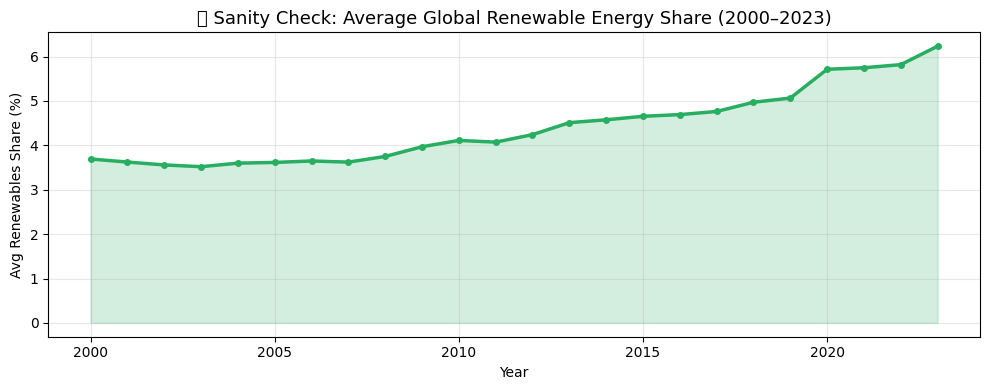

📈 Trend looks correct — renewables growing over time!


In [25]:
# Quick visual check: global renewable share trend
world_trend = df.groupby('year')['renewables_share_energy'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(world_trend['year'], world_trend['renewables_share_energy'],
         color='#27ae60', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(world_trend['year'], world_trend['renewables_share_energy'],
                 alpha=0.2, color='#27ae60')
plt.title('✅ Sanity Check: Average Global Renewable Energy Share (2000–2023)', fontsize=13)
plt.xlabel('Year')
plt.ylabel('Avg Renewables Share (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('📈 Trend looks correct — renewables growing over time!')

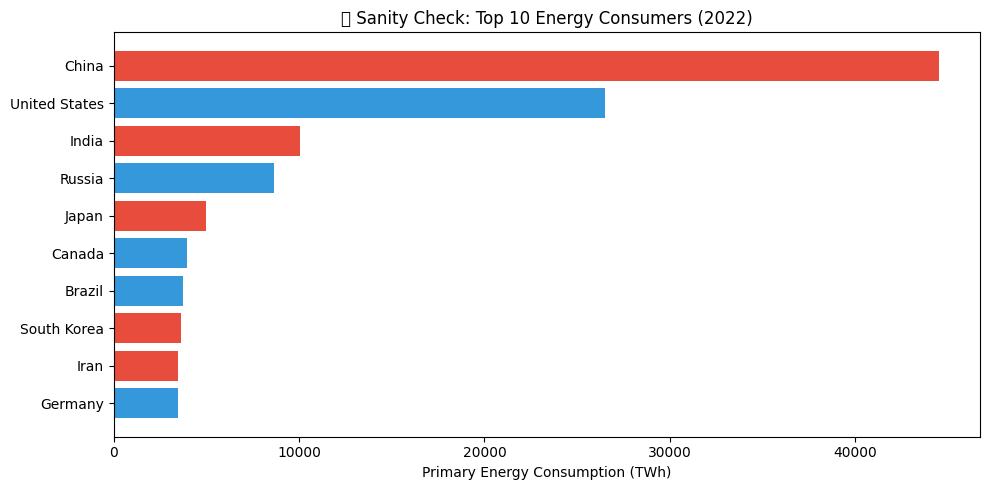

In [26]:
# Top 10 energy consumers in 2022
latest = df[df['year'] == 2022].dropna(subset=['primary_energy_consumption'])
top10 = latest.nlargest(10, 'primary_energy_consumption')[['country', 'primary_energy_consumption', 'continent']]

plt.figure(figsize=(10, 5))
colors = ['#3498db' if c != 'Asia' else '#e74c3c' for c in top10['continent']]
plt.barh(top10['country'][::-1], top10['primary_energy_consumption'][::-1], color=colors[::-1])
plt.xlabel('Primary Energy Consumption (TWh)')
plt.title('✅ Sanity Check: Top 10 Energy Consumers (2022)')
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ Export Cleaned Dataset

In [27]:
# Export to CSV
output_path = '/content/owid-energy-data.csv'
df.to_csv(output_path, index=False)

print(f'✅ Cleaned dataset saved to: {output_path}')
print(f'   Shape: {df.shape}')
print(f'   Size : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Columns in cleaned dataset:')
for col in df.columns:
    null_pct = df[col].isna().sum() / len(df) * 100
    print(f'  {col:<40} null: {null_pct:.1f}%')

✅ Cleaned dataset saved to: /content/owid-energy-data.csv
   Shape: (5260, 39)
   Size : 2565.3 KB

Columns in cleaned dataset:
  country                                  null: 0.0%
  year                                     null: 0.0%
  iso_code                                 null: 0.0%
  population                               null: 0.7%
  gdp                                      null: 24.8%
  primary_energy_consumption               null: 1.0%
  energy_per_capita                        null: 1.7%
  energy_per_gdp                           null: 28.1%
  coal_consumption                         null: 0.0%
  gas_consumption                          null: 0.0%
  oil_consumption                          null: 0.0%
  fossil_fuel_consumption                  null: 0.0%
  fossil_share_energy                      null: 2.9%
  renewables_consumption                   null: 0.0%
  renewables_share_energy                  null: 2.9%
  solar_consumption                        null: 0.0%
  wind

**Download Cleaned Data**

In [28]:
# Download cleaned dataset
from google.colab import files
files.download('/content/owid-energy-data.csv')
print('✅ Download started!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


## ✅ Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Removed aggregate regions | Kept real countries only |
| 2 | Filtered years | 2000–2023 |
| 3 | Selected 38 relevant columns | Dropped 92 irrelevant columns |
| 4 | Filled energy source NaNs with 0 | Countries with no source = 0 |
| 5 | Forward/backward filled GDP | Stable economic indicator |
| 6 | Added continent column | For regional analysis |
| 7 | Derived fossil/renewable shares | From component columns |
| 8 | Added gdp_per_capita | For scatter/bubble charts |
| 9 | Added dominant_source label | For categorical analysis |

